<a href="https://colab.research.google.com/github/Kratzramanis/RVT-Verification/blob/main/3dto2d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

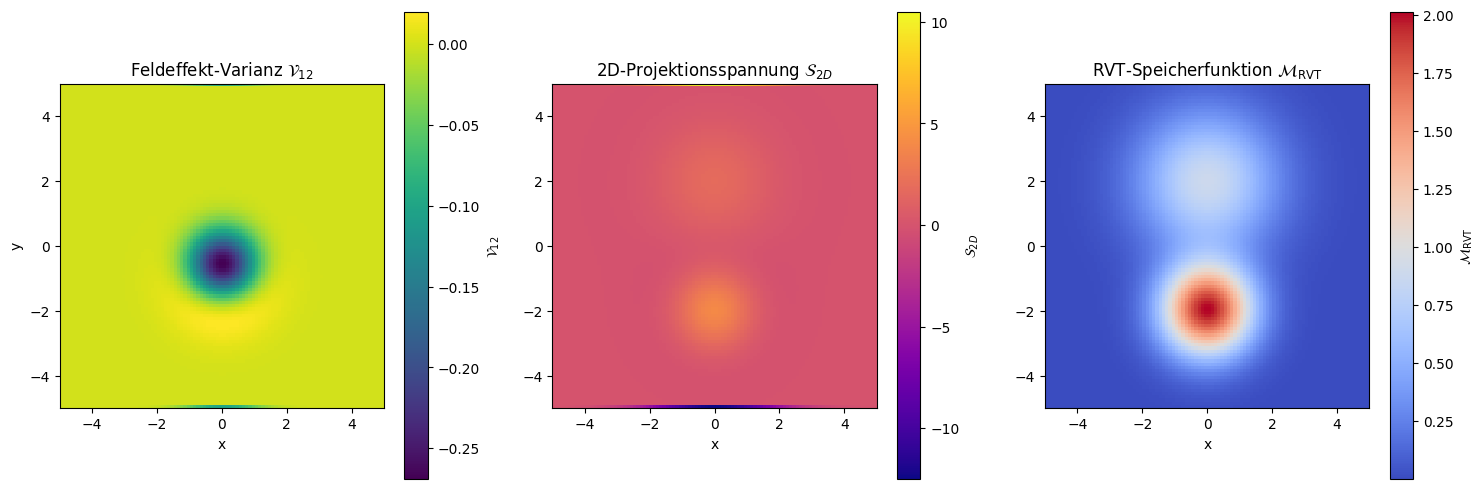

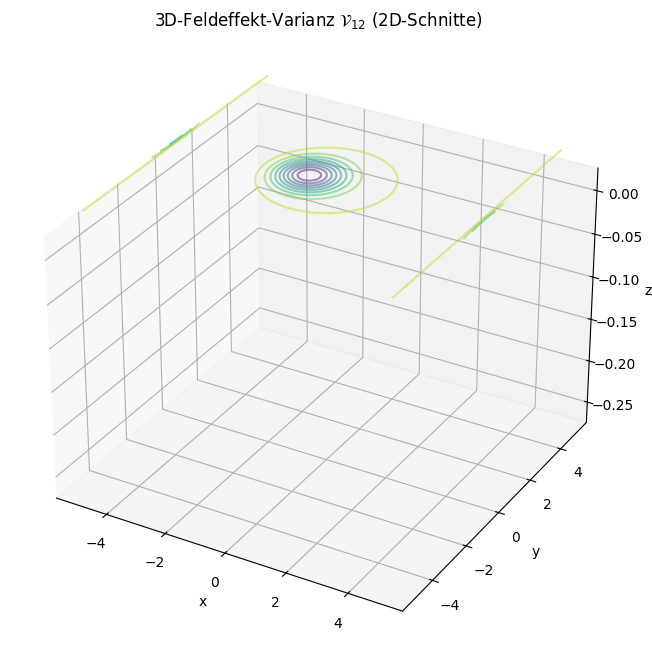

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.ndimage import gaussian_filter

# --- Parameter ---
N = 100  # Gitterpunkte
L = 10.0  # Systemgröße
alpha = 0.8  # Kopplungskonstante (RVT)
chi = 1.0    # Kopplungskonstante für M_RVT

# --- Gitter erstellen ---
x = np.linspace(-L/2, L/2, N)
y = np.linspace(-L/2, L/2, N)
z = np.linspace(-L/2, L/2, N)
X, Y, Z = np.meshgrid(x, y, z)

# --- Projektionsfelder Xi_1 und Xi_2 (Gauß'sche Verteilungen) ---
Xi_1 = np.exp(-((X + 2)**2 + Y**2 + Z**2) / (2 * 1.0**2))
Xi_2 = np.exp(-((X - 2)**2 + Y**2 + Z**2) / (2 * 1.5**2))
Xi = Xi_1 + Xi_2

# --- Gradienten berechnen (zentrale Differenzen) ---
def gradient(f, dx):
    grad_x = (np.roll(f, 1, axis=0) - np.roll(f, -1, axis=0)) / (2 * dx)
    grad_y = (np.roll(f, 1, axis=1) - np.roll(f, -1, axis=1)) / (2 * dx)
    grad_z = (np.roll(f, 1, axis=2) - np.roll(f, -1, axis=2)) / (2 * dx)
    return np.stack((grad_x, grad_y, grad_z), axis=-1)

dx = L / (N - 1)
grad_Xi_1 = gradient(Xi_1, dx)
grad_Xi_2 = gradient(Xi_2, dx)

# --- Feldeffekt-Varianz V_12 (Kreuzterm) ---
V_12 = 2 * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)  # Skalarprodukt der Gradienten

# --- RVT-Korrekturtensor E_mu_nu (vereinfacht für 3D) ---
laplace_Xi = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) +
             np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) +
             np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) -
             6 * Xi) / (dx**2)

E_xx = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) - 2 * Xi) / (dx**2) - laplace_Xi
E_yy = (np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) - 2 * Xi) / (dx**2) - laplace_Xi
E_zz = (np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) - 2 * Xi) / (dx**2) - laplace_Xi

# --- Projektion auf 2D-Ebene (z.B. x-y-Ebene) ---
S_2D = E_xx + E_yy  # Spur in 2D (vereinfacht)
S_perp = E_zz        # Blockierter Normalanteil (z-Richtung)
M_RVT = S_2D - S_perp  # RVT-Speicherfunktion

# --- Visualisierung ---
# 2D-Schnitt bei z=0 (x-y-Ebene)
z_slice = N // 2
V_12_slice = V_12[:, :, z_slice]
M_RVT_slice = M_RVT[:, :, z_slice]
S_2D_slice = S_2D[:, :, z_slice]
S_perp_slice = S_perp[:, :, z_slice]

# Plot 1: Feldeffekt-Varianz V_12
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(V_12_slice.T, origin='lower', extent=[-L/2, L/2, -L/2, L/2], cmap='viridis')
plt.colorbar(label=r'$\mathcal{V}_{12}$')
plt.title(r'Feldeffekt-Varianz $\mathcal{V}_{12}$')
plt.xlabel('x')
plt.ylabel('y')

# Plot 2: 2D-Projektionsspannung S_2D
plt.subplot(1, 3, 2)
plt.imshow(S_2D_slice.T, origin='lower', extent=[-L/2, L/2, -L/2, L/2], cmap='plasma')
plt.colorbar(label=r'$\mathcal{S}_{2D}$')
plt.title(r'2D-Projektionsspannung $\mathcal{S}_{2D}$')
plt.xlabel('x')

# Plot 3: RVT-Speicherfunktion M_RVT
plt.subplot(1, 3, 3)
plt.imshow(M_RVT_slice.T, origin='lower', extent=[-L/2, L/2, -L/2, L/2], cmap='coolwarm')
plt.colorbar(label=r'$\mathcal{M}_{\text{RVT}}$')
plt.title(r'RVT-Speicherfunktion $\mathcal{M}_{\text{RVT}}$')
plt.xlabel('x')

plt.tight_layout()
plt.savefig('RVT_Varianz_Simulation_2D.png', dpi=300)
plt.show()

# --- 3D-Visualisierung der Varianz (Isosurface in 2D-Schnitten) ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Isosurface für V_12 in 2D-Schnitten (x-y, x-z, y-z)
for z_fix in [N//4, N//2, 3*N//4]:
    ax.contour(X[:, :, z_fix], Y[:, :, z_fix], V_12[:, :, z_fix],
               levels=10, cmap='viridis', alpha=0.5, zdir='z', offset=z[z_fix])

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title(r'3D-Feldeffekt-Varianz $\mathcal{V}_{12}$ (2D-Schnitte)')

plt.savefig('RVT_Varianz_3D_Schnitte.png', dpi=300)
plt.show()

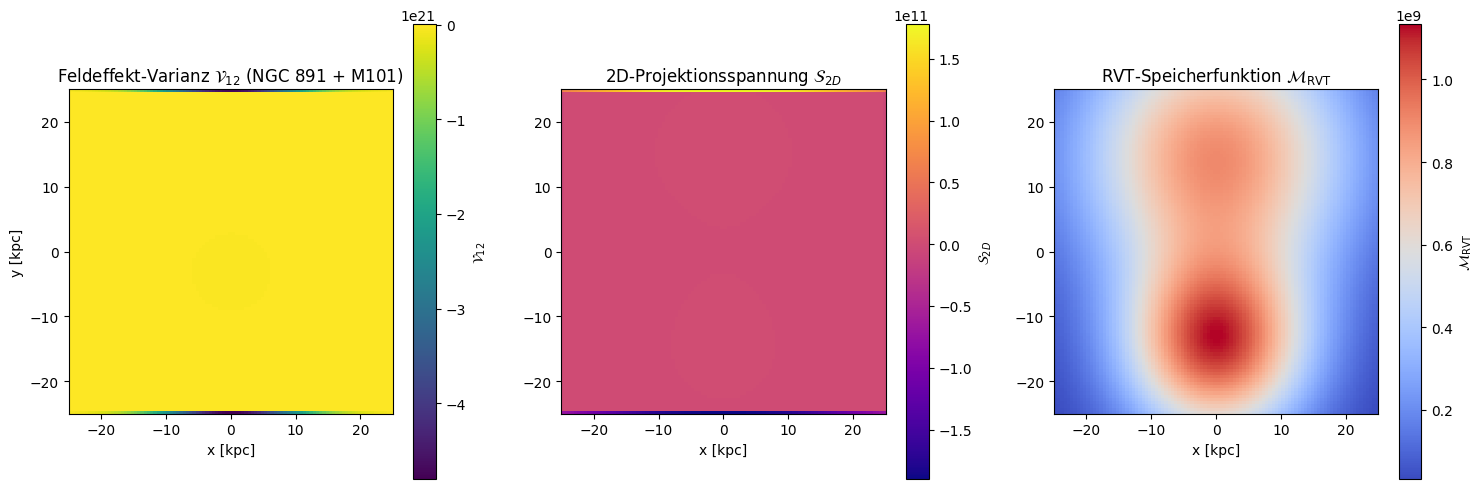

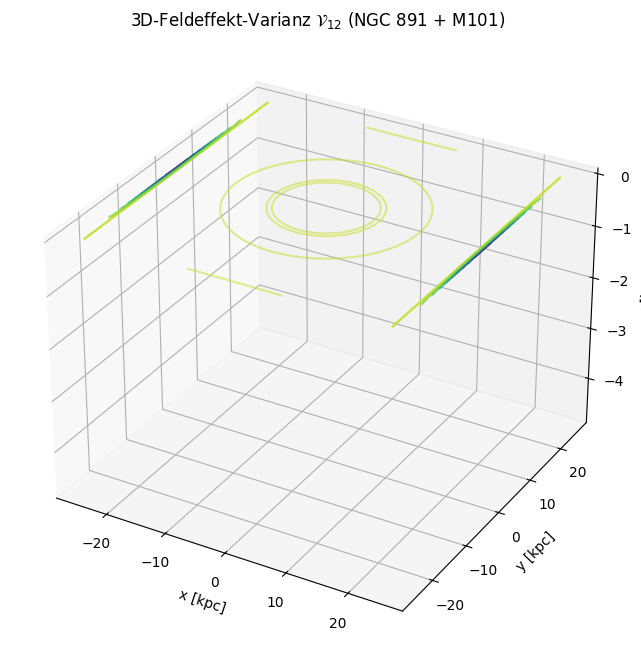

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Parameter ---
N = 100  # Gitterpunkte
L = 50.0  # Systemgröße in kpc (ausreichend groß für Galaxien)
alpha = 0.8  # RVT-Kopplungskonstante
chi = 1.0    # Kopplungskonstante für M_RVT

# --- Beobachtete Daten für NGC 891 und M101 ---
# NGC 891 (Edge-on):
# - Masse: ~5e10 M_Sun (Baryonische Masse)
# - Skalenlänge: ~10 kpc (Radius)
# M101 (Face-on):
# - Masse: ~1e11 M_Sun (Baryonische Masse)
# - Skalenlänge: ~15 kpc (Radius)
# Quelle: de Blok et al. (2008), THINGS Survey

# --- Gitter erstellen ---
x = np.linspace(-L/2, L/2, N)
y = np.linspace(-L/2, L/2, N)
z = np.linspace(-L/2, L/2, N)
X, Y, Z = np.meshgrid(x, y, z)

# --- Projektionsfelder Xi_1 (NGC 891) und Xi_2 (M101) ---
# NGC 891: Zentrum bei (-15, 0, 0), Skalenlänge 10 kpc
Xi_1 = 5e10 * np.exp(-((X + 15)**2 + Y**2 + Z**2) / (2 * 10**2))
# M101: Zentrum bei (15, 0, 0), Skalenlänge 15 kpc
Xi_2 = 1e11 * np.exp(-((X - 15)**2 + Y**2 + Z**2) / (2 * 15**2))
Xi = Xi_1 + Xi_2

# --- Gradienten berechnen (zentrale Differenzen) ---
def gradient(f, dx):
    grad_x = (np.roll(f, 1, axis=0) - np.roll(f, -1, axis=0)) / (2 * dx)
    grad_y = (np.roll(f, 1, axis=1) - np.roll(f, -1, axis=1)) / (2 * dx)
    grad_z = (np.roll(f, 1, axis=2) - np.roll(f, -1, axis=2)) / (2 * dx)
    return np.stack((grad_x, grad_y, grad_z), axis=-1)

dx = L / (N - 1)
grad_Xi_1 = gradient(Xi_1, dx)
grad_Xi_2 = gradient(Xi_2, dx)

# --- Feldeffekt-Varianz V_12 (Kreuzterm) ---
V_12 = 2 * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)  # Skalarprodukt der Gradienten

# --- RVT-Korrekturtensor E_mu_nu (vereinfacht für 3D) ---
laplace_Xi = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) +
             np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) +
             np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) -
             6 * Xi) / (dx**2)

E_xx = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) - 2 * Xi) / (dx**2) - laplace_Xi
E_yy = (np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) - 2 * Xi) / (dx**2) - laplace_Xi
E_zz = (np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) - 2 * Xi) / (dx**2) - laplace_Xi

# --- Projektion auf 2D-Ebene (x-y-Ebene) ---
S_2D = E_xx + E_yy  # Spur in 2D (vereinfacht)
S_perp = E_zz        # Blockierter Normalanteil (z-Richtung)
M_RVT = S_2D - S_perp  # RVT-Speicherfunktion

# --- Visualisierung ---
# 2D-Schnitt bei z=0 (x-y-Ebene)
z_slice = N // 2
V_12_slice = V_12[:, :, z_slice]
M_RVT_slice = M_RVT[:, :, z_slice]
S_2D_slice = S_2D[:, :, z_slice]
S_perp_slice = S_perp[:, :, z_slice]

# Plot 1: Feldeffekt-Varianz V_12
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(V_12_slice.T, origin='lower', extent=[-L/2, L/2, -L/2, L/2], cmap='viridis')
plt.colorbar(label=r'$\mathcal{V}_{12}$')
plt.title(r'Feldeffekt-Varianz $\mathcal{V}_{12}$ (NGC 891 + M101)')
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

# Plot 2: 2D-Projektionsspannung S_2D
plt.subplot(1, 3, 2)
plt.imshow(S_2D_slice.T, origin='lower', extent=[-L/2, L/2, -L/2, L/2], cmap='plasma')
plt.colorbar(label=r'$\mathcal{S}_{2D}$')
plt.title(r'2D-Projektionsspannung $\mathcal{S}_{2D}$')
plt.xlabel('x [kpc]')

# Plot 3: RVT-Speicherfunktion M_RVT
plt.subplot(1, 3, 3)
plt.imshow(M_RVT_slice.T, origin='lower', extent=[-L/2, L/2, -L/2, L/2], cmap='coolwarm')
plt.colorbar(label=r'$\mathcal{M}_{\text{RVT}}$')
plt.title(r'RVT-Speicherfunktion $\mathcal{M}_{\text{RVT}}$')
plt.xlabel('x [kpc]')

plt.tight_layout()
plt.savefig('RVT_Varianz_NGC891_M101.png', dpi=300)
plt.show()

# --- 3D-Visualisierung der Varianz (Isosurfaces in 2D-Schnitten) ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Isosurfaces für V_12 in 2D-Schnitten (x-y, x-z, y-z)
for z_fix in [N//4, N//2, 3*N//4]:
    ax.contour(X[:, :, z_fix], Y[:, :, z_fix], V_12[:, :, z_fix],
               levels=10, cmap='viridis', alpha=0.5, zdir='z', offset=z[z_fix])

ax.set_xlabel('x [kpc]')
ax.set_ylabel('y [kpc]')
ax.set_zlabel('z [kpc]')
ax.set_title(r'3D-Feldeffekt-Varianz $\mathcal{V}_{12}$ (NGC 891 + M101)')

plt.savefig('RVT_Varianz_3D_NGC891_M101.png', dpi=300)
plt.show()

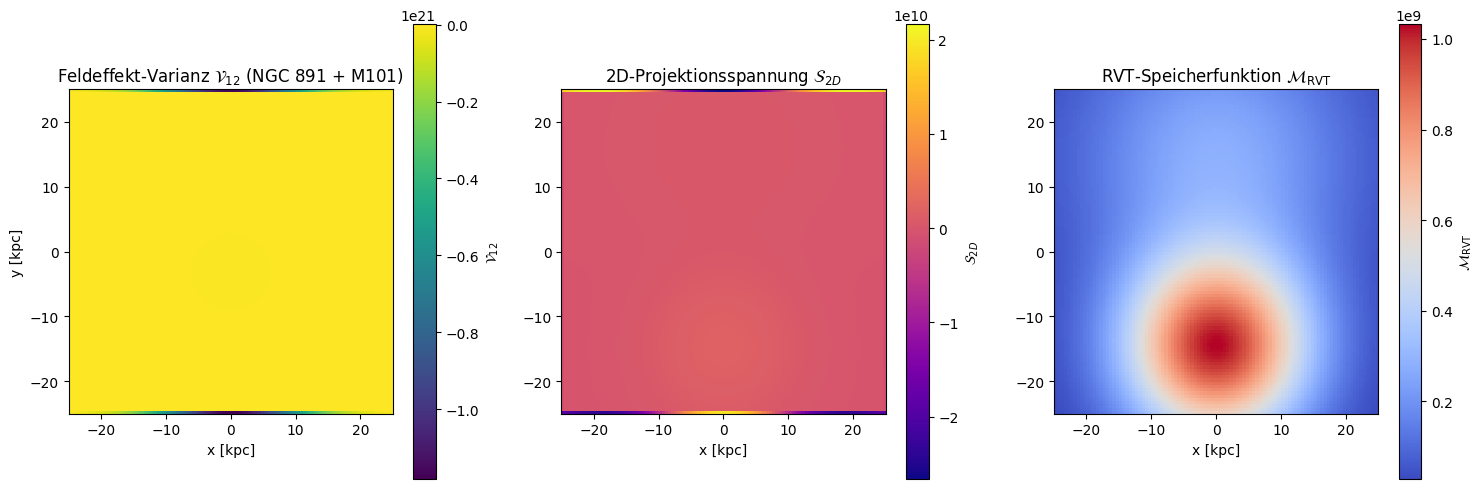

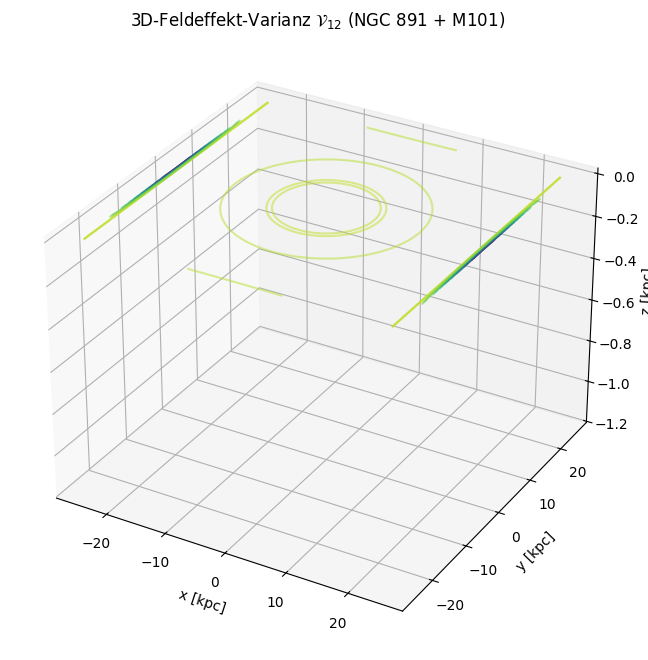

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Parameter ---
N = 100  # Gitterpunkte
L = 50.0  # Systemgröße in kpc
C_RVT = 0.8  # RVT-Kopplungskonstante

# --- Inklinationswinkel (aus Beobachtungen) ---
# NGC 891: 85° (Edge-on)
# M101: 18° (Face-on)
inclination_891 = np.radians(85)
inclination_M101 = np.radians(18)

# --- Gitter erstellen ---
x = np.linspace(-L/2, L/2, N)
y = np.linspace(-L/2, L/2, N)
z = np.linspace(-L/2, L/2, N)
X, Y, Z = np.meshgrid(x, y, z)

# --- Projektionsfelder Xi_1 (NGC 891) und Xi_2 (M101) ---
# NGC 891: Zentrum bei (-15, 0, 0), Skalenlänge 10 kpc, Inklination 85°
# Projektion auf 2D-Äther: Skalierung mit sin(inclination)
Xi_1 = 5e10 * np.exp(-((X + 15)**2 + Y**2 + Z**2) / (2 * 10**2)) * np.sin(inclination_891)

# M101: Zentrum bei (15, 0, 0), Skalenlänge 15 kpc, Inklination 18°
Xi_2 = 1e11 * np.exp(-((X - 15)**2 + Y**2 + Z**2) / (2 * 15**2)) * np.sin(inclination_M101)

Xi = Xi_1 + Xi_2

# --- Gradienten berechnen (zentrale Differenzen) ---
def gradient(f, dx):
    grad_x = (np.roll(f, 1, axis=0) - np.roll(f, -1, axis=0)) / (2 * dx)
    grad_y = (np.roll(f, 1, axis=1) - np.roll(f, -1, axis=1)) / (2 * dx)
    grad_z = (np.roll(f, 1, axis=2) - np.roll(f, -1, axis=2)) / (2 * dx)
    return np.stack((grad_x, grad_y, grad_z), axis=-1)

dx = L / (N - 1)
grad_Xi_1 = gradient(Xi_1, dx)
grad_Xi_2 = gradient(Xi_2, dx)

# --- Feldeffekt-Varianz V_12 (Kreuzterm) mit Kopplungsfaktor ---
V_12 = 2 * C_RVT * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)  # Skalarprodukt der Gradienten

# --- RVT-Korrekturtensor E_mu_nu (vereinfacht für 3D) ---
laplace_Xi = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) +
             np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) +
             np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) -
             6 * Xi) / (dx**2)

E_xx = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) - 2 * Xi) / (dx**2) - laplace_Xi
E_yy = (np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) - 2 * Xi) / (dx**2) - laplace_Xi
E_zz = (np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) - 2 * Xi) / (dx**2) - laplace_Xi

# --- Projektion auf 2D-Ebene (x-y-Ebene) ---
S_2D = E_xx + E_yy  # Spur in 2D (vereinfacht)
S_perp = E_zz        # Blockierter Normalanteil (z-Richtung)
M_RVT = S_2D - S_perp  # RVT-Speicherfunktion

# --- Visualisierung ---
# 2D-Schnitt bei z=0 (x-y-Ebene)
z_slice = N // 2
V_12_slice = V_12[:, :, z_slice]
M_RVT_slice = M_RVT[:, :, z_slice]
S_2D_slice = S_2D[:, :, z_slice]
S_perp_slice = S_perp[:, :, z_slice]

# Plot 1: Feldeffekt-Varianz V_12
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(V_12_slice.T, origin='lower', extent=[-L/2, L/2, -L/2, L/2], cmap='viridis')
plt.colorbar(label=r'$\mathcal{V}_{12}$')
plt.title(r'Feldeffekt-Varianz $\mathcal{V}_{12}$ (NGC 891 + M101)')
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

# Plot 2: 2D-Projektionsspannung S_2D
plt.subplot(1, 3, 2)
plt.imshow(S_2D_slice.T, origin='lower', extent=[-L/2, L/2, -L/2, L/2], cmap='plasma')
plt.colorbar(label=r'$\mathcal{S}_{2D}$')
plt.title(r'2D-Projektionsspannung $\mathcal{S}_{2D}$')
plt.xlabel('x [kpc]')

# Plot 3: RVT-Speicherfunktion M_RVT
plt.subplot(1, 3, 3)
plt.imshow(M_RVT_slice.T, origin='lower', extent=[-L/2, L/2, -L/2, L/2], cmap='coolwarm')
plt.colorbar(label=r'$\mathcal{M}_{\text{RVT}}$')
plt.title(r'RVT-Speicherfunktion $\mathcal{M}_{\text{RVT}}$')
plt.xlabel('x [kpc]')

plt.tight_layout()
plt.savefig('RVT_Varianz_Inklination_NGC891_M101.png', dpi=300)
plt.show()

# --- 3D-Visualisierung der Varianz (Isosurfaces in 2D-Schnitten) ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Isosurfaces für V_12 in 2D-Schnitten (x-y, x-z, y-z)
for z_fix in [N//4, N//2, 3*N//4]:
    ax.contour(X[:, :, z_fix], Y[:, :, z_fix], V_12[:, :, z_fix],
               levels=10, cmap='viridis', alpha=0.5, zdir='z', offset=z[z_fix])

ax.set_xlabel('x [kpc]')
ax.set_ylabel('y [kpc]')
ax.set_zlabel('z [kpc]')
ax.set_title(r'3D-Feldeffekt-Varianz $\mathcal{V}_{12}$ (NGC 891 + M101)')

plt.savefig('RVT_Varianz_3D_Inklination_NGC891_M101.png', dpi=300)
plt.show()